# STEP 9. 결과: 네트워크 정의별 공원 묶음과 고립 공원

**목적**: STEP 7의 강건한 묶음(robust groups)과 persistence를 정의별로 정리하고 지도로 보여 준다.

**읽는 법**
- **묶음(group)**: 파라미터 설정의 과반(평균 동반소속 ≥ 0.5)에서 같은 연결요소에 함께 속한 공원 집합. 괄호 안 g70은 평균 동반소속 ≥ 0.7인 더 엄격한 묶음.
- **강건 고립**: IsolationPersistence ≥ 0.8. 거의 모든 설정에서 다른 공원과 configurational 관계가 없다.
- **unresolved**: 네트워크 attachment가 작은 연결요소에만 있어(OSM 누락 가능성) 판정을 보류한 공원.

**출력**: `outputs/{AREA}/park_results.csv`, `map_{def}.html`, `groups_{def}.png`, `cross_definition_status.png`

In [1]:
# ===== 공통 설정 (모든 STEP 노트북에서 동일) =====
import os
import json
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import geopandas as gpd

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 30)

# 분석 지역: "Brooklyn"(파일럿) 또는 "NYC"(전체). 환경변수 PARK_STUDY_AREA로도 지정 가능.
STUDY_AREA = os.environ.get("PARK_STUDY_AREA", "Brooklyn")

ROOT = Path.cwd()
DATA = ROOT / "Data"
PARKS_PATH = DATA / "NYCPark" / "Parks_Properties_20260923.geojson"
NET_DIR = DATA / "derived" / "network"        # STEP1 결과 (지역 무관, NYC+버퍼 전체)
AREA_DIR = DATA / "derived" / STUDY_AREA      # STEP2 이후 결과
OUT_DIR = ROOT / "outputs" / STUDY_AREA
for _d in (NET_DIR, AREA_DIR, OUT_DIR):
    _d.mkdir(parents=True, exist_ok=True)

CRS = 32618            # UTM 18N (m)
R_MAX = 3200           # 탐색 한계 (m) = 보로 네트워크 버퍼 폭
SPEED = 1.0            # speed_m_s=1 -> agg_seconds == 경로 길이(m)

BOROUGHS = {"M": "Manhattan", "X": "Bronx", "B": "Brooklyn", "Q": "Queens", "R": "Staten Island"}
AREA_BOROUGHS = ["B"] if STUDY_AREA == "Brooklyn" else list(BOROUGHS)

# 네트워크 변형: C = 가로 중심선 + 보행전용 경로 (주 분석), S = 보도 포함 전체 보행망 (민감도)
VARIANTS = ["C", "S"]
PRIMARY = "C"
SIDEWALK_FOOTWAYS = {"sidewalk", "crossing", "traffic_island"}

# 공원 필터 (사용자 결정): Flagship + 비공원성 필지 제외, 면적 상한 100 acres (계산은 200 상위집합)
EXCLUDE_TYPES = ["Flagship Park", "Operations", "Lot", "Undeveloped",
                 "Buildings/Institutions", "Cemetery", "Managed Sites"]
AREA_CAP = 100
AREA_CAP_SUPERSET = 200
AREA_CAP_GRID = [50, 100, 200]
RESTRICTED_TYPES = ["Garden", "Jointly Operated Playground"]            # 접근 제한 민감도
STREET_EMBEDDED_TYPES = ["Triangle/Plaza", "Strip", "Mall", "Parkway"]  # 가로 매몰형 민감도

# 공원-네트워크 attachment
ATTACH_BUFFER = {"C": 20.0, "S": 10.0}   # 경계 버퍼 (m): C는 중심선이 도로 폭 절반만큼 떨어져 있음
ATTACH_BUFFER_GRID = {"C": [15.0, 20.0, 30.0], "S": [5.0, 10.0, 20.0]}
INSIDE_SHARE = 0.9       # 공원 내부에 90% 이상 들어간 세그먼트는 attachment에서 제외 (통행은 허용)
K_SOURCES = 8            # 공원당 출발 attachment 최대 개수 (farthest-point sampling)
SMALL_COMPONENT = 200    # 이보다 작은 연결요소에만 붙은 공원은 'unresolved'

# 최종 묶음 공통 절차: 설정별 Louvain(γ) → 보로 단위 퍼콜레이션 필터 → 합의 ≥ 0.5 → 도보 10분 지름 분할
MAIN_GAMMA = 2
COMMERCIAL_BUFFER = 100   # 연구 개요: 군집 구성 공원 주변 100 m = 상업 영역

# 묶음 크기 제약: 묶음 안 모든 공원 쌍이 서로 도보 10분 이내 (보행망 최단거리, 1.33 m/s × 600 s ≈ 800 m)
WALK_LIMIT = 800
WALK_LIMIT_GRID = [400, 800, 1200]   # 5 / 10 / 15분 민감도

# N1 angular few-turn
N1_THETAS = [15, 45, 90, 180]
N1_RADII = [800, 1600, 3200]
N1_REL_Q = [0.1, 0.2]
DIST_BANDS = [0, 200, 400, 800, 1600, 3200]

# D walking distance (근접성 기준선): 보행망 최단거리 ≤ d 이면 연결
D_DISTS = [200, 400, 800]

# N2 street-axis continuity: 같은 연속 가로(stroke) 위, 두 공원 구간 사이 간격 ≤ lim
N2_ALONG = [400, 800, 1600]
# (큰길 속성 계산용) 각도 choice/NACH 반경과 상위 비율
N2_RADII = [800, 1600, 3200]
N2_TOP_P = [0.02, 0.05, 0.10]
STROKE_ANGLE = 30
STROKE_ANGLE_GRID = [20, 30, 45]
N2_MAX_ALONG = [3200, None]

# N3 excess few-turn field overlap
N3_THETAS = [45, 90]
N3_RADII = [800, 1600]
N3_TAU = [0.1, 0.2]
N3_KAPPA = [1.0, 1.25]

print(f"STUDY_AREA={STUDY_AREA}  boroughs={AREA_BOROUGHS}  AREA_DIR={AREA_DIR.relative_to(ROOT)}")

STUDY_AREA=Brooklyn  boroughs=['B']  AREA_DIR=Data/derived/Brooklyn


In [2]:
import folium
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

parks = gpd.read_parquet(NET_DIR / "parks.parquet")
DEFINITIONS = ["D", "N1abs", "N1rel", "N2", "N3"]
LABELS = {"D": "D walking distance (proximity baseline)", "N1abs": "N1 angular few-turn (absolute θ)",
          "N1rel": "N1 angular few-turn (relative, distance-banded)",
          "N2": "N2 street-axis continuity", "N3": "N3 excess few-turn field overlap"}
G = {d: pd.read_parquet(AREA_DIR / f"robust_groups_{d}.parquet") for d in DEFINITIONS}
verdict = pd.read_csv(AREA_DIR / "evaluation_verdict.csv", index_col=0)
PIDS = G[DEFINITIONS[0]].index
base = parks.loc[PIDS, ["name", "typecategory", "borough", "acres", "geometry"]]

## 9-1. 공원별 결과 테이블

In [3]:
res = base.drop(columns="geometry").copy()
for d in DEFINITIONS:
    g = G[d]
    res[f"{d}_group"] = g.group_g50
    res[f"{d}_group_size"] = g.size_g50
    res[f"{d}_group_strict"] = g.group_g70
    res[f"{d}_iso"] = g.iso.round(3)
    res[f"{d}_grouped"] = g.grouped.round(3)
    res[f"{d}_core"] = g.core.round(3)
    res[f"{d}_status"] = np.select(
        [g.unresolved >= 0.5, g.iso >= 0.8, g.group_g50 >= 0], ["unresolved", "robust isolated", "grouped"], "unstable")
res.to_csv(OUT_DIR / "park_results.csv")
status = pd.DataFrame({d: res[f"{d}_status"].value_counts() for d in DEFINITIONS}).fillna(0).astype(int)
status.loc["groups (g50)"] = [res[f"{d}_group"].pipe(lambda s: s[s >= 0].nunique()) for d in DEFINITIONS]
status.loc["proximity AUC (median)"] = [round(verdict.median_AUC.get(d, np.nan), 3) for d in DEFINITIONS]
status

,D,N1abs,N1rel,N2,N3
grouped,544.0,514.00,588.000,467.000,56.000
robust isolated,11.0,14.00,31.000,93.000,481.000
unresolved,2.0,2.00,2.000,2.000,2.000
unstable,64.0,91.00,0.000,59.000,82.000
groups (g50),70.0,58.00,6.000,62.000,22.000
proximity AUC (median),NaN,0.77,0.599,0.978,0.734


## 9-2. 정의별 가장 큰 묶음

In [4]:
for d in DEFINITIONS:
    g = res[res[f"{d}_group"] >= 0].groupby(f"{d}_group")
    top = g.agg(size=("name", "size"), acres=("acres", "sum"),
                members=("name", lambda s: ", ".join(s.head(6)) + (" …" if len(s) > 6 else ""))) \
        .sort_values("size", ascending=False).head(8)
    print(f"\n### {LABELS[d]}")
    display(top)


### D walking distance (proximity baseline)


,size,acres,members
D_group,,,
9,45,179.243,"Eastern Parkway (10/10), Eastern Parkway (4/10..."
66,39,16.458,"Martin Luther King Jr. Playground, Grace Playg..."
49,37,32.015,"Herbert Von King Park, Banneker Playground, Ra..."
33,29,13.058,"Sobel Playground, Cohn Triangle, William Sheri..."
94,20,49.390,"Commodore Barry Park, McLaughlin Park, Cadman ..."
95,20,35.885,"Fort Stirling Park, Van Voorhees Playground, P..."
86,19,15.840,"Veterans Triangle, Lion's Pride Playground, Va..."
2,18,72.791,"Coffey Park, St. Mary's Park, St. Mary's Park,..."



### N1 angular few-turn (absolute θ)


,size,acres,members
N1abs_group,,,
7,53,114.772,"American Playground, Orient Grove, Cooper Park..."
23,48,28.070,"Martin Luther King Jr. Playground, Grace Playg..."
71,36,375.225,"Brower Park, Eastern Parkway (10/10), Eastern ..."
47,30,27.759,"Beattie Square, Herbert Von King Park, Taaffe ..."
107,30,394.672,"Fort Hamilton Triangle, John Paul Jones Park, ..."
84,30,59.210,"Fort Stirling Park, McLaughlin Park, Cadman Pl..."
53,26,187.956,"Commodore Barry Park, Cuyler Gore Park, Easter..."
34,19,18.704,"Betsy Head Park, Zion Triangle, Howard Malls, ..."



### N1 angular few-turn (relative, distance-banded)


,size,acres,members
N1rel_group,,,
3,132,219.116,"Beattie Square, Maria Hernandez Park, Bushwick..."
6,126,712.828,"Bartel-Pritchard Square, Carroll Park, Fort Ha..."
4,111,201.321,"Betsy Head Park, Veterans Triangle, Highland P..."
5,100,450.078,"Amersfort Park, Bensonhurst Park, Kelly Park P..."
1,70,664.254,"Brower Park, Eastern Parkway (1/10), Eastern P..."
2,49,114.174,"American Playground, Sarah J.S. Tompkins Garne..."



### N2 street-axis continuity


,size,acres,members
N2_group,,,
33,45,102.857,"American Playground, Fidelity Triangle, Greenp..."
7,41,24.166,"Martin Luther King Jr. Playground, Grace Playg..."
1,36,78.814,"Commodore Barry Park, Fort Stirling Park, McLa..."
20,32,157.228,"Eastern Parkway (10/10), Eastern Parkway (4/10..."
15,29,30.035,"Betsy Head Park, Veterans Triangle, Howard Mal..."
62,24,20.416,"Beattie Square, Herbert Von King Park, Banneke..."
22,18,167.115,"Eastern Parkway (2/10), Eastern Parkway (5/10)..."
3,18,72.163,"Carroll Park, Van Voorhees Playground, St. Mar..."



### N3 excess few-turn field overlap


,size,acres,members
N3_group,,,
155,8,2.253,"Brooklyn Heights Promenade, Brooklyn Heights P..."
5,3,0.547,"Sh'ma Yisrael, Imani II Community Garden, King..."
61,3,5.499,"Raymond Bush Playground, P.O. Reinaldo Salgado..."
103,3,0.221,"First Quincy St Block Association, Patrick Van..."
8,3,1.675,"Decatur Playground, 700 Decatur St Block Assoc..."
68,3,0.245,"Welcome Home Garden, Halsey Ralph & Howard Com..."
24,3,0.356,"Vernon Tandt Block Association, Vernon/throop ..."
44,2,1.956,"Albert L. Parham Playground, Oracle Playground"


## 9-3. 정적 지도: 정의별 묶음 (색 = 묶음, 빨강 = 강건 고립, 회색 = 불안정, 검정 테두리 = unresolved)

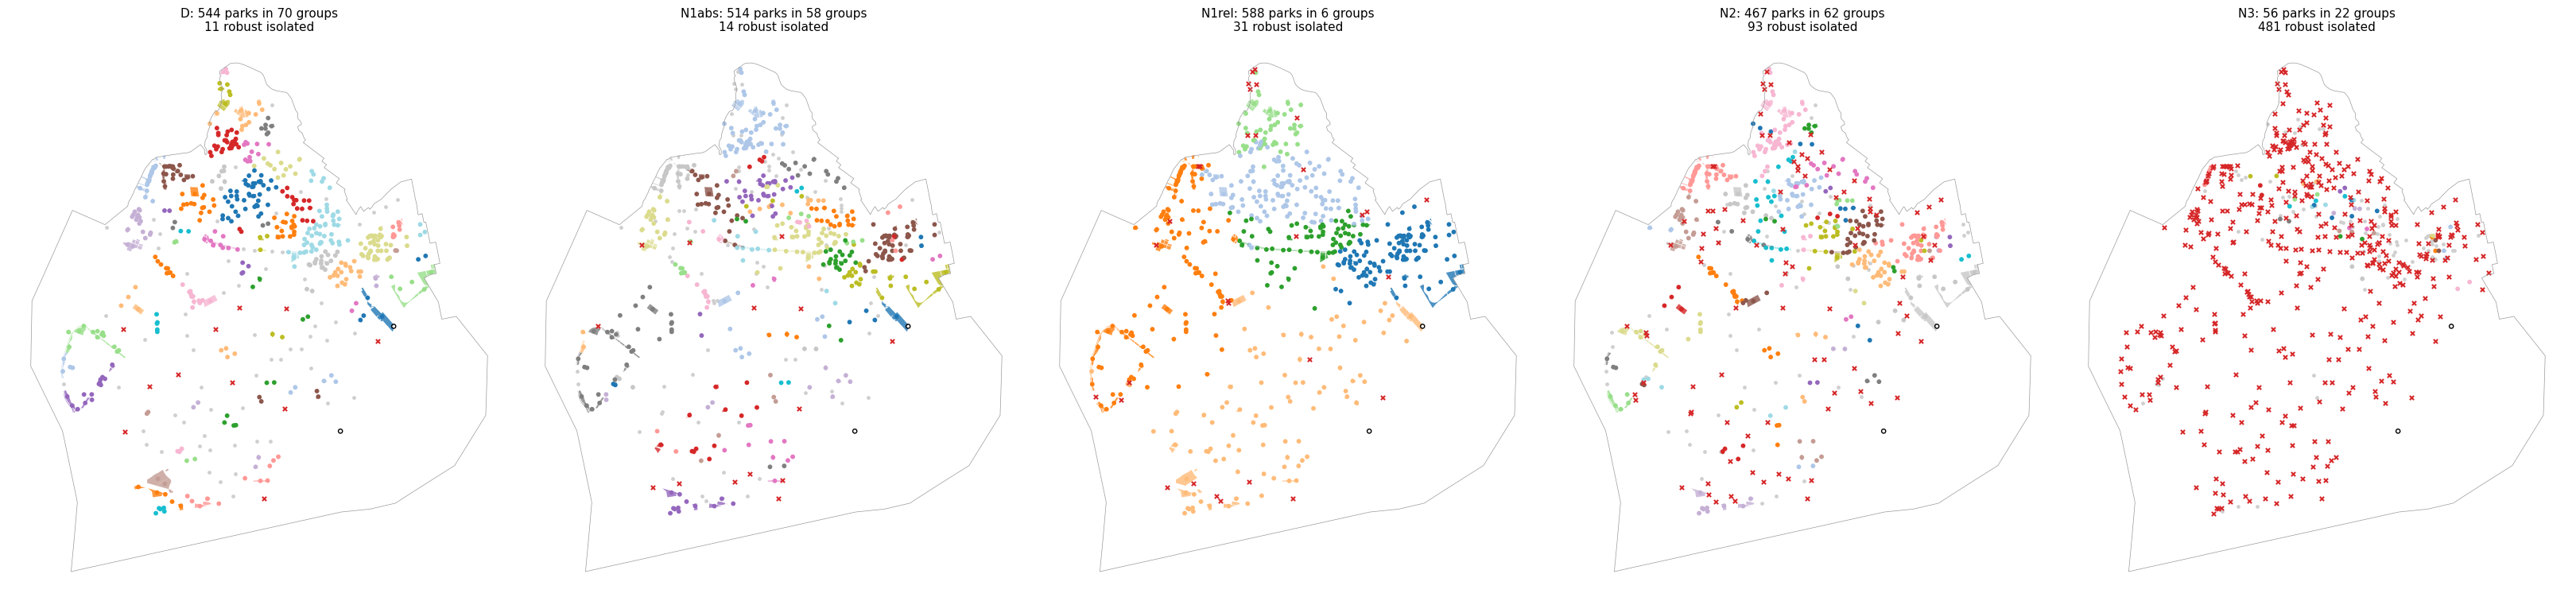

In [5]:
def group_colors(labels, seed=0):
    ids = sorted(labels[labels >= 0].unique())
    rng = np.random.default_rng(seed)
    cmap = plt.get_cmap("tab20")
    cols = {gid: mcolors.to_hex(cmap(k % 20)) for k, gid in enumerate(rng.permutation(ids))}
    return cols


boroughs = gpd.read_file(NET_DIR / "boundaries.gpkg", layer="boroughs").set_index("borough").loc[AREA_BOROUGHS]
n = len(DEFINITIONS)
fig, axes = plt.subplots(1, n, figsize=(6.5 * n, 8))
for ax, d in zip(axes, DEFINITIONS):
    gdf = base.join(res[[f"{d}_group", f"{d}_status"]])
    cols = group_colors(gdf[f"{d}_group"])
    boroughs.boundary.plot(ax=ax, color="#999999", linewidth=0.5)
    pts = gdf.copy()
    pts["geometry"] = gdf.geometry.representative_point()
    grey = pts[pts[f"{d}_status"] == "unstable"]
    if len(grey):
        grey.plot(ax=ax, color="#cfcfcf", markersize=6)
    grp = pts[pts[f"{d}_group"] >= 0]
    grp.plot(ax=ax, color=grp[f"{d}_group"].map(cols), markersize=10)
    gdf[gdf[f"{d}_group"] >= 0].plot(ax=ax, color=gdf.loc[gdf[f"{d}_group"] >= 0, f"{d}_group"].map(cols), alpha=0.8)
    pts[pts[f"{d}_status"] == "robust isolated"].plot(ax=ax, color="#d62728", markersize=14, marker="x")
    pts[pts[f"{d}_status"] == "unresolved"].plot(ax=ax, facecolor="none", edgecolor="black", markersize=14)
    ax.set_title(f"{d}: {int((gdf[f'{d}_group'] >= 0).sum())} parks in {gdf.loc[gdf[f'{d}_group'] >= 0, f'{d}_group'].nunique()} groups\n"
                 f"{int((gdf[f'{d}_status'] == 'robust isolated').sum())} robust isolated", fontsize=11)
    ax.set_axis_off()
plt.tight_layout()
fig.savefig(OUT_DIR / "groups_all_definitions.png", dpi=160)
plt.show()

## 9-4. 인터랙티브 지도 (folium): 정의별 HTML
공원을 클릭하면 이름, 유형, 면적, 묶음 번호, persistence가 보인다.

In [6]:
def folium_map(d):
    gdf = base.join(res[[f"{d}_group", f"{d}_group_size", f"{d}_status", f"{d}_iso", f"{d}_grouped", f"{d}_core"]])
    cols = group_colors(gdf[f"{d}_group"])
    gdf["color"] = np.where(gdf[f"{d}_group"] >= 0, gdf[f"{d}_group"].map(cols),
                            np.where(gdf[f"{d}_status"] == "robust isolated", "#d62728", "#9e9e9e"))
    g4 = gdf.to_crs(4326).reset_index()
    g4["acres"] = g4.acres.round(2)
    center = g4.geometry.union_all().centroid
    m = folium.Map(location=[center.y, center.x], zoom_start=12, tiles="CartoDB positron")
    folium.GeoJson(
        g4[["park_id", "name", "typecategory", "acres", f"{d}_group", f"{d}_group_size", f"{d}_status",
            f"{d}_iso", f"{d}_grouped", f"{d}_core", "color", "geometry"]],
        style_function=lambda f: {"fillColor": f["properties"]["color"], "color": f["properties"]["color"],
                                  "weight": 1.5, "fillOpacity": 0.75},
        tooltip=folium.GeoJsonTooltip(fields=["name", "typecategory", "acres", f"{d}_group", f"{d}_group_size",
                                              f"{d}_status", f"{d}_iso", f"{d}_grouped", f"{d}_core"]),
        name=d,
    ).add_to(m)
    title = f"<h4 style='position:fixed;top:10px;left:50px;z-index:9999;background:white;padding:6px'>{LABELS[d]} — {STUDY_AREA}</h4>"
    m.get_root().html.add_child(folium.Element(title))
    m.save(OUT_DIR / f"map_{d}.html")
    return m


for d in DEFINITIONS:
    folium_map(d)
print("saved:", sorted(p.name for p in OUT_DIR.glob("map_*.html")))
folium_map("N2")

saved: ['map_D.html', 'map_N1abs.html', 'map_N1rel.html', 'map_N2.html', 'map_N3.html']


## 9-5. 정의 간 교차: 세 정의(N1 주 정의, N2, N3) 모두에서 묶이는 공원 vs 모두에서 고립되는 공원
N1abs와 N1rel은 같은 관계(쌍별 각도 비용)의 두 임계 방식이므로 한 정의로 센다. STEP 8 판정에 따라 근접성 지배가 아닌 쪽을 N1 주 정의로 쓴다.

cross-definition set: ['N1abs', 'N2', 'N3']


,parks
cross_status,
grouped in ≥2,411
isolated in ≥2,81
definition-specific,64
grouped in all,52
isolated in all,13


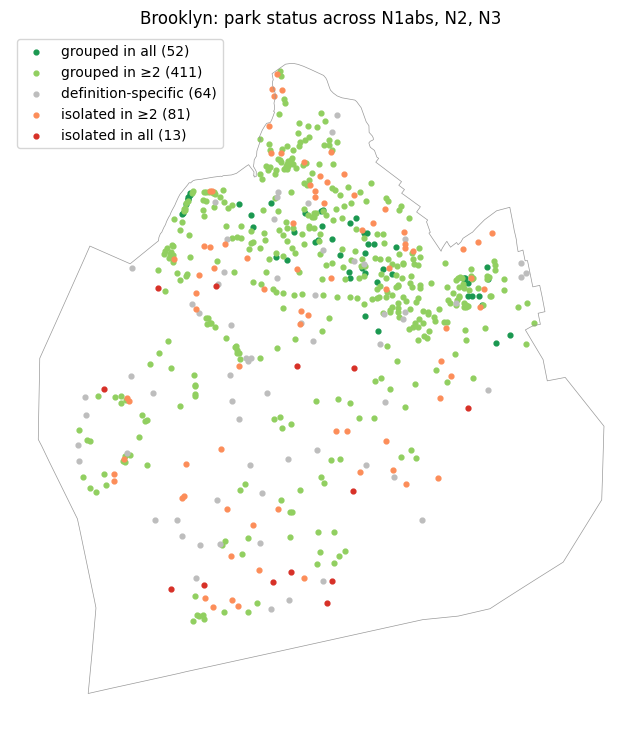

In [7]:
N1_MAIN = "N1rel" if bool(verdict.loc["N1abs", "proximity_dominated"]) else "N1abs"
CROSS = [N1_MAIN, "N2", "N3"]
print("cross-definition set:", CROSS)
st = res[[f"{d}_status" for d in CROSS]]
res["n_grouped"] = (st == "grouped").sum(axis=1)
res["n_isolated"] = (st == "robust isolated").sum(axis=1)
res["cross_status"] = np.select(
    [res.n_grouped == len(CROSS), res.n_isolated == len(CROSS), res.n_grouped >= 2, res.n_isolated >= 2],
    ["grouped in all", "isolated in all", "grouped in ≥2", "isolated in ≥2"], "definition-specific")
res.to_csv(OUT_DIR / "park_results.csv")
display(res.cross_status.value_counts().to_frame("parks"))

palette = {"grouped in all": "#1a9850", "grouped in ≥2": "#91cf60", "definition-specific": "#bdbdbd",
           "isolated in ≥2": "#fc8d59", "isolated in all": "#d73027"}
fig, ax = plt.subplots(figsize=(9, 9))
boroughs.boundary.plot(ax=ax, color="#999999", linewidth=0.5)
pts = base.join(res[["cross_status"]])
pts["geometry"] = pts.geometry.representative_point()
for k, col in palette.items():
    sub = pts[pts.cross_status == k]
    if len(sub):
        sub.plot(ax=ax, color=col, markersize=12, label=f"{k} ({len(sub)})")
ax.legend(loc="upper left")
ax.set_title(f"{STUDY_AREA}: park status across {', '.join(CROSS)}")
ax.set_axis_off()
fig.savefig(OUT_DIR / "cross_definition_status.png", dpi=160)
plt.show()

## 9-6. 강건 고립 공원 목록 (세 정의 모두에서)
N2·N3에서의 고립은 "주요 회랑에 없음"·"few-turn 장 겹침이 거리 기대 이상이 아님"이라는 뜻이라 흔하다. 그래서 N1 주 정의에서도 고립인 공원이 핵심 목록이다.

In [8]:
iso_list = res[res.cross_status == "isolated in all"].sort_values("acres", ascending=False)
iso_list[["name", "typecategory", "acres"] + [f"{d}_iso" for d in DEFINITIONS]]

,name,typecategory,acres,D_iso,N1abs_iso,N1rel_iso,N2_iso,N3_iso
park_id,,,,,,,,
B082#5,Shore Park and Parkway (5/10),Community Park,58.000,0.000,0.833,0.5,1.0,1.0
B251,Manhattan Beach Park,Community Park,42.941,1.000,1.000,1.0,1.0,1.0
B166C,Coney Island Boat Basin,Recreational Field/Courts,36.810,0.000,0.875,1.0,1.0,1.0
B379,Coney Island Creek Park,Nature Area,8.892,0.333,0.875,1.0,1.0,1.0
B275,Grady Playground,Jointly Operated Playground,3.403,0.667,0.917,1.0,1.0,1.0
B166B,Homecrest Playground,Playground,2.372,0.667,0.833,0.0,1.0,1.0
B111A,Washington Skate Park,Jointly Operated Playground,1.549,0.000,0.833,0.0,1.0,1.0
B274,Bayview Playground,Jointly Operated Playground,1.210,1.000,0.833,0.0,1.0,1.0
B234,Tilden Playground,Neighborhood Park,1.190,1.000,0.833,0.0,1.0,1.0
